In [1]:
from collections import Counter
from itertools import combinations
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
import requests
from datetime import datetime
from Bio import SeqIO
from Bio.Seq import Seq

from Levenshtein import distance as lev_distance  # pip install python-Levenshtein

from dnsmex.local import localify
from netam.sequences import translate_sequence, AA_STR_SORTED

figures_dir = localify("FIGURES_DIR")

For this analysis, we use the OGRDB reference files. 
The reference files used by partis also come from this dataset, so the two are directly comparable. The key difference is that we download the gapped version of the OGRDB references, because the gaps preserve IMGT numbering. We also compared the gene IDs and they are the same. Thus we can use the OGRDB reference to annotate the files classified by partis.

In this analysis
- We create reference files that we can later merge onto sitewise dataframes to add gemrline annotations per v gene.
- We calculate the similarities between the different v genes and plot that.

In [2]:
## Download the FASTA file from OGRDB of gapped germline VDJ sequences


# URL of the FASTA file
url = "https://ogrdb.airr-community.org/download_germline_set/Human/IGH_VDJ/published/gapped_ex"

# Create directory if it doesn't exist
os.makedirs("germline", exist_ok=True)

# Generate filename with today's date
today_date = datetime.now().strftime("%Y%m%d")
filename = f"germline/ogrdb_human_IGH_{today_date}.fasta"

# Download the file
print("Downloading FASTA file...")
response = requests.get(url)
response.raise_for_status()  # Raise an exception for bad status codes

# Save the file
with open(filename, "wb") as f:
    f.write(response.content)

print(f"File downloaded successfully as {filename}!")

# Read FASTA and convert to DataFrame
records = []
for record in SeqIO.parse(filename, "fasta"):
    records.append({
        'id': record.id,
        'sequence': str(record.seq),
        'length': len(record.seq)
    })

df = pd.DataFrame(records)
print(f"\nLoaded {len(df)} sequences")
print(df.head())

# Optional: Display some basic statistics
print(f"\nSequence length statistics:")
print(df['length'].describe())
print(f"\nExample sequence IDs:")
print(df['id'].head(10).tolist())

File downloaded successfully as germline/ogrdb_human_IGH_20250910.fasta!

Loaded 236 sequences
            id              sequence  length
0   IGHD1-1*01     GGTACAACTGGAACGAC      17
1  IGHD1-14*01     GGTATAACCGGAACCAC      17
2  IGHD1-20*01     GGTATAACTGGAACGAC      17
3  IGHD1-26*01  GGTATAGTGGGAGCTACTAC      20
4   IGHD1-7*01     GGTATAACTGGAACTAC      17

Sequence length statistics:
count    236.000000
mean     273.474576
std      107.096950
min       11.000000
25%      320.000000
50%      320.000000
75%      320.000000
max      322.000000
Name: length, dtype: float64

Example sequence IDs:
['IGHD1-1*01', 'IGHD1-14*01', 'IGHD1-20*01', 'IGHD1-26*01', 'IGHD1-7*01', 'IGHD2-15*01', 'IGHD2-2*01', 'IGHD2-2*02', 'IGHD2-21*01', 'IGHD2-21*02']


In [3]:
df = df[df.id.str.startswith('IGHV')]
df.rename(columns={'id':'v_gene'}, inplace=True)
df['v_family'] = df['v_gene'].str.split('-').str[0]


In [4]:
## since this is nucleotides, make sure that the gaps are of a codon and not nucleotide per codon so that we can translate easily to amino acids. They are
for seq in df.sequence.tolist():
    counts = Counter([i // 3 for i in  range(len(seq)) if seq[i] == '.'])
    print([i == 3 for i in counts.values()])
    #print(counts)


[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True]
[True, True, True, T

In [5]:
codons_df = []
for row in df.itertuples():
    sequence = row[2]
    seq_df = pd.DataFrame(list(enumerate([sequence[i:i+3] for i in range(0, len(sequence), 3)], start=1)), columns=['site', 'codon'])
    seq_df['v_gene'] = row[1]
    seq_df['v_family'] = row[4]
    codons_df.append(seq_df)

codons_df = pd.concat(codons_df, ignore_index=True)
codons_df = codons_df[(codons_df['codon'] != '...') & (codons_df['codon'].str.len() == 3)]  # Filter to ensure codons are of length 3 and remove gaps

# remove v genes that have stop codons in them - likely psuedogenes??
codons_df = codons_df[~codons_df.v_gene.isin(codons_df[codons_df['codon'].isin(['TGA', 'TAG'])].v_gene.unique().tolist())]

codons_df['amino_acid'] = codons_df['codon'].apply(translate_sequence)
codons_df

,site,codon,v_gene,v_family,amino_acid
0,1,CAG,IGHV1-18*01,IGHV1,Q
1,2,GTT,IGHV1-18*01,IGHV1,V
2,3,CAG,IGHV1-18*01,IGHV1,Q
3,4,CTG,IGHV1-18*01,IGHV1,L
4,5,GTG,IGHV1-18*01,IGHV1,V
...,...,...,...,...,...
21203,102,TTT,IGHV8-51-1*05,IGHV8,F
21204,103,AAC,IGHV8-51-1*05,IGHV8,N
21205,104,TGT,IGHV8-51-1*05,IGHV8,C
21206,105,GCA,IGHV8-51-1*05,IGHV8,A


In [6]:
#### save germline annotations so we can later add to sitewise dataframes
codons_df.to_csv(localify(f"germline/germline_codons.csv"), index=False)

In [7]:
# calculate distance between v genes

def calculate_similarity(df, level="nucleotide", metric="hamming"):
    """
    Calculate pairwise similarity between v_genes using nucleotides or amino acids,
    with Hamming or Levenshtein distance. Missing codons are treated as gaps.
    
    Args:
        df : DataFrame with columns ['v_gene', 'site', 'codon']
        level : str, "nucleotide" or "aa"
        metric : str, "hamming" or "levenshtein"
        
    Returns:
        similarity_matrix : pandas DataFrame
    """
    
    # Pivot into codon matrix (missing codons remain NaN)
    codon_matrix = df.pivot(index='v_gene', columns='site', values='codon')
    
    if level == "aa":
        # Translate codons using Biopython
        def translate_codon(c):
            if pd.isnull(c):
                return '-'  # gap
            try:
                return str(Seq(c).translate(to_stop=False))
            except:
                return 'X'  # unknown codon
        
        matrix = codon_matrix.applymap(translate_codon)
        # Concatenate amino acids into sequences
        seqs = matrix.apply(lambda row: ''.join(row.values), axis=1)
        
    elif level == "nucleotide":
        # Split codons into individual nucleotides
        def split_codon(c):
            if pd.isnull(c):
                return ['-','-','-']  # gap for missing codon
            return list(c)
        
        # Expand each codon column into 3 nucleotide columns
        nuc_matrix = pd.DataFrame(index=codon_matrix.index)
        for col in codon_matrix.columns:
            split_cols = codon_matrix[col].apply(split_codon)
            nuc_matrix = pd.concat([nuc_matrix, pd.DataFrame(split_cols.tolist(),
                                                             index=codon_matrix.index,
                                                             columns=[f"{col}_1", f"{col}_2", f"{col}_3"])],
                                   axis=1)
        # Concatenate nucleotides into full sequences
        seqs = nuc_matrix.apply(lambda row: ''.join(row.values), axis=1)
    
    else:
        raise ValueError("level must be 'nucleotide' or 'aa'")
    
    # Initialize similarity matrix
    indices = seqs.index
    similarity_matrix = pd.DataFrame(index=indices, columns=indices, dtype=float)
    
    # Pairwise comparisons
    for gene1, gene2 in combinations(indices, 2):
        s1, s2 = seqs[gene1], seqs[gene2]
        
        if metric == "hamming":
            paired = [(a, b) for a, b in zip(s1, s2) if a != '-' and b != '-']
            if len(paired) == 0:
                similarity = np.nan
            else:
                identical = sum(a == b for a, b in paired)
                similarity = identical / len(paired)
        
        elif metric == "levenshtein":
            dist = lev_distance(s1, s2)
            max_len = max(len(s1), len(s2))
            similarity = 1 - (dist / max_len if max_len > 0 else 0.0)
        
        else:
            raise ValueError("metric must be 'hamming' or 'levenshtein'")
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Self-similarity = 1
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix


distance_hamming_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="hamming")
distance_hamming_aa = calculate_similarity(codons_df, level="aa", metric="hamming")
distance_levenshtein_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="levenshtein")
distance_levenshtein_aa = calculate_similarity(codons_df, level="aa", metric="levenshtein")


/tmp/ipykernel_1561644/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)
/tmp/ipykernel_1561644/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


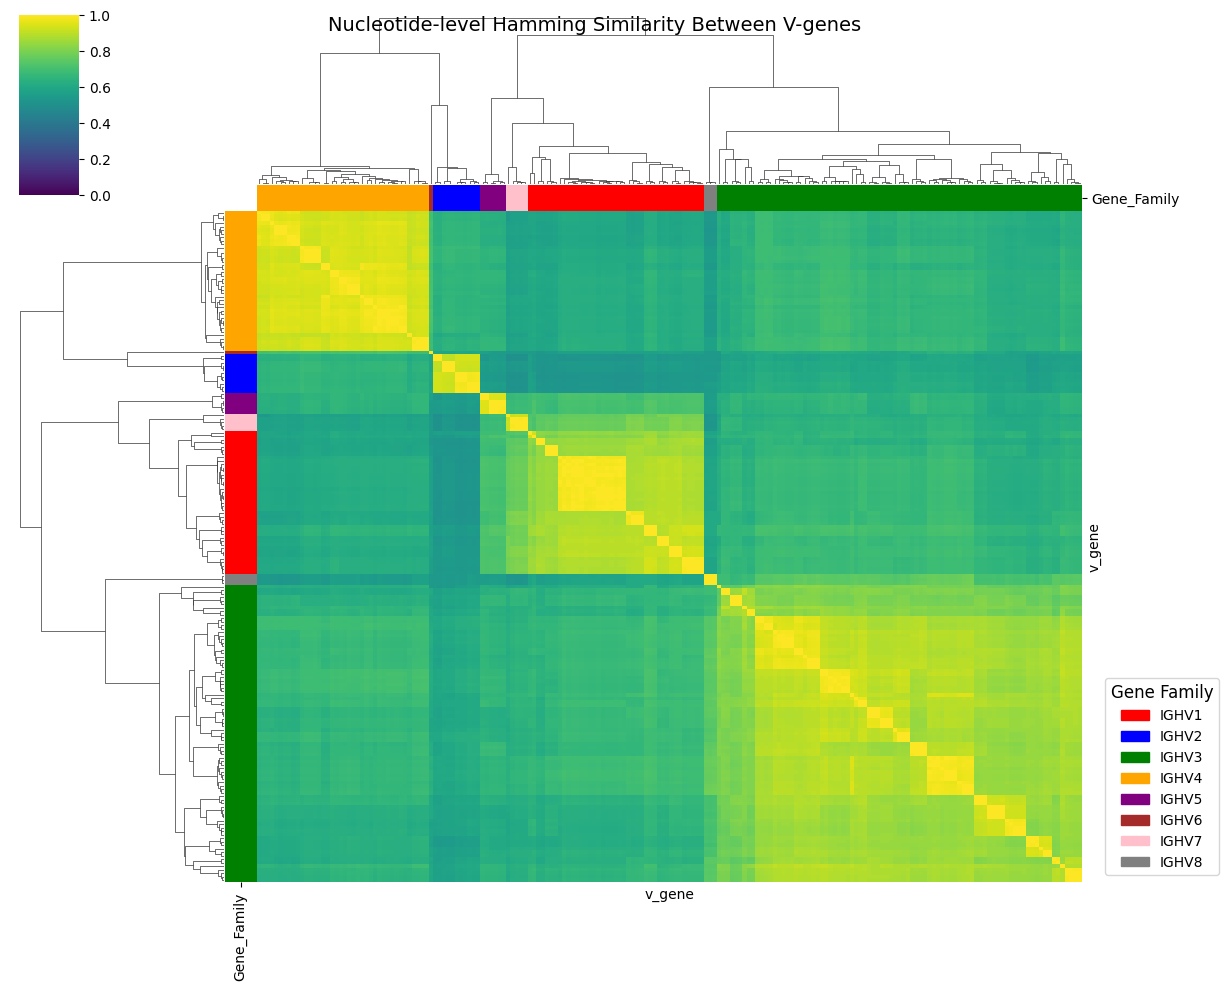

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


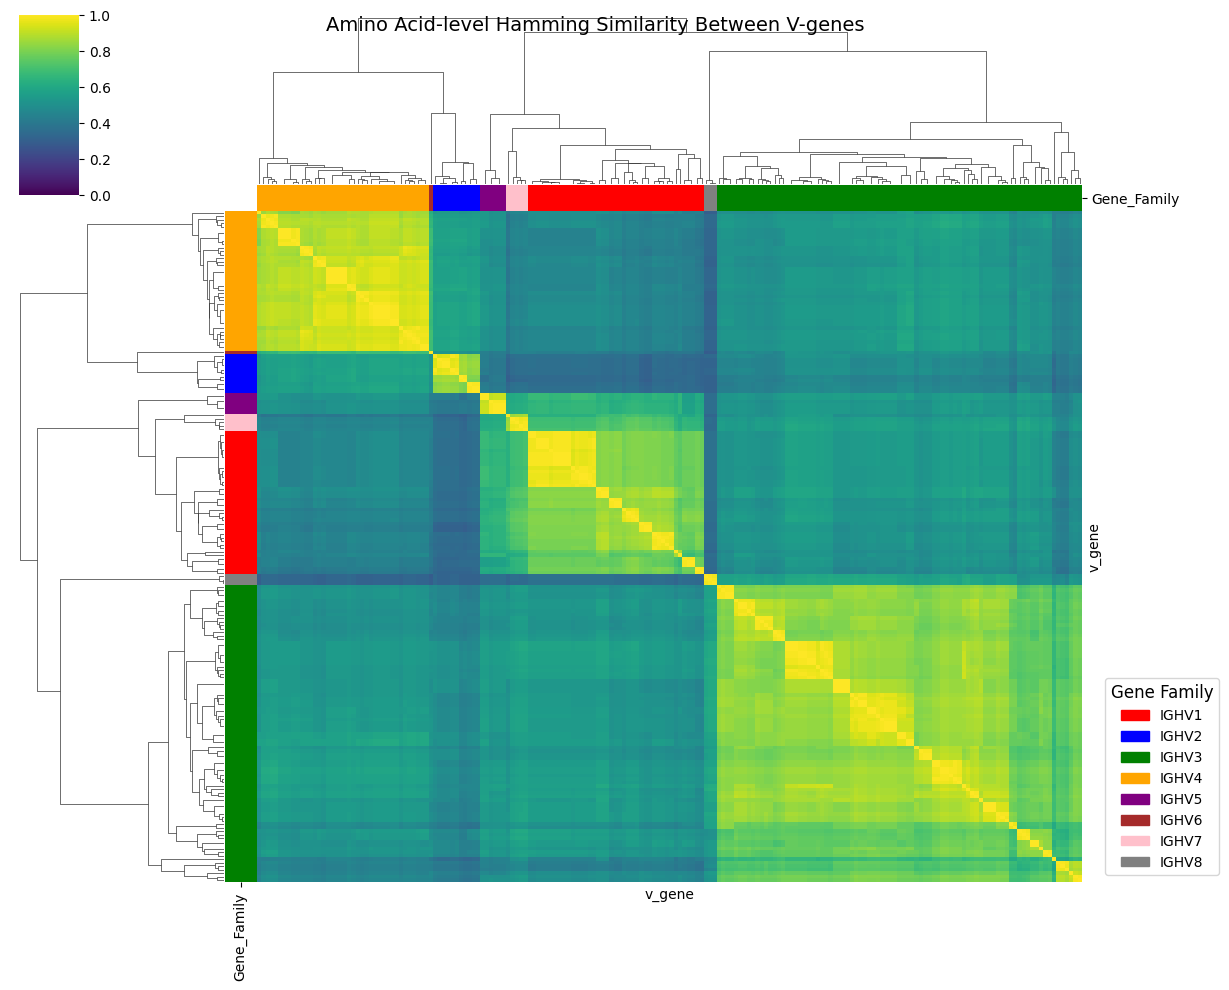

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


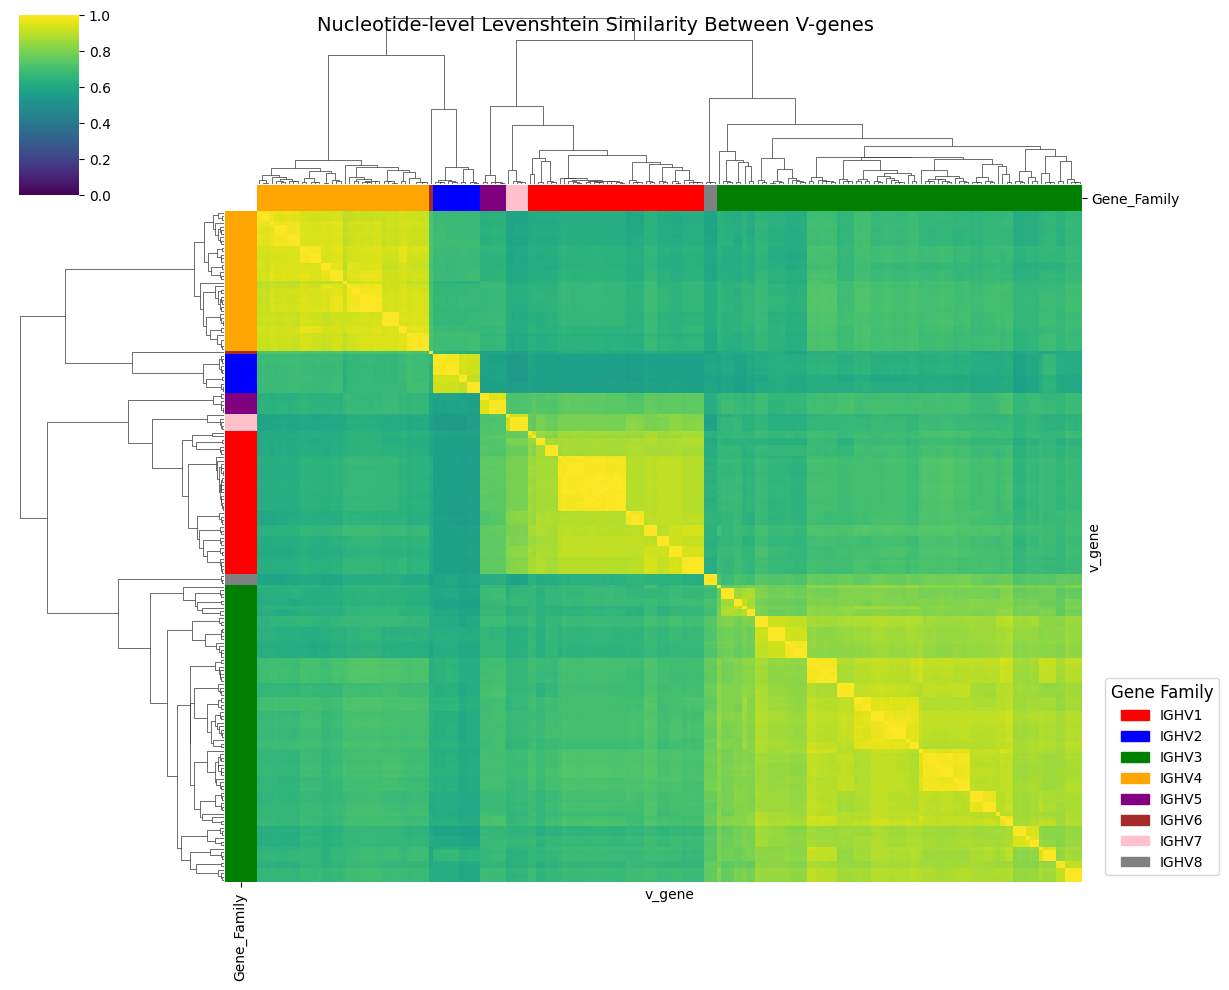

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


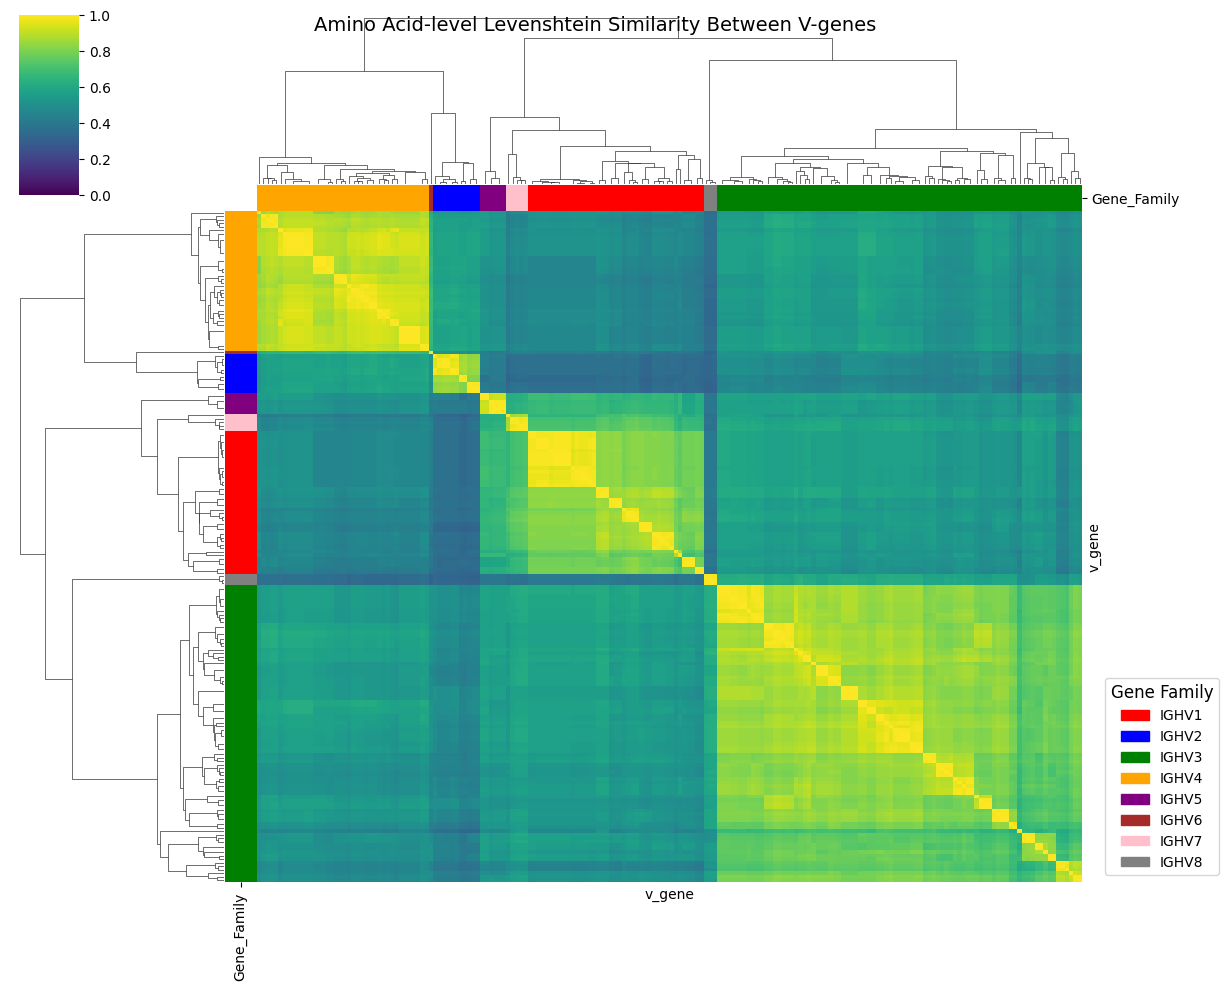

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink
IGHV8: gray


In [8]:


def plot_similarity_clustermap(similarity_df, codons_df, title):
    """
    Plot a clustermap of gene similarity with gene family color bars.
    
    Args:
        similarity_df : DataFrame (square similarity matrix, index = v_genes)
        codons_df : DataFrame containing ['v_gene', 'v_family']
        title : str, title for the plot
    """
    
    # --- Gene family dictionary ---
    gene_family_dict = {i[1]: i[2] 
                        for i in list(codons_df[['v_gene', 'v_family']]
                                      .drop_duplicates().itertuples())}
    
    # Clean allele info (*01, *02, etc.)
    gene_family_dict_clean = {gene.split('*')[0]: family 
                              for gene, family in gene_family_dict.items()}
    
    # Unique families → assign colors
    unique_families = sorted(set(gene_family_dict_clean.values()))
    named_colors = ['red', 'blue', 'green', 'orange', 'purple', 
                    'brown', 'pink', 'gray', 'cyan', 'olive']
    category_colors_named = dict(zip(unique_families, 
                                     named_colors[:len(unique_families)]))
    
    # Cleaned gene names for mapping
    clean_index = [gene.split('*')[0] for gene in similarity_df.index]
    clean_columns = [gene.split('*')[0] for gene in similarity_df.columns]
    
    # Row & column colors
    row_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_index, index=similarity_df.index)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    col_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_columns, index=similarity_df.columns)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    
    # --- Clustermap ---
    g = sns.clustermap(similarity_df,
                       cmap='viridis',
                       square=True,
                       xticklabels=False,
                       yticklabels=False,
                       row_colors=row_colors_df,
                       col_colors=col_colors_df,
                       figsize=(12, 10),
                       vmin=0, vmax=1)
    
    # Title
    g.fig.suptitle(title, fontsize=14, y=0.98)
    
    # Legend for families
    legend_patches = [mpatches.Patch(color=color, label=family) 
                      for family, color in sorted(category_colors_named.items())]
    
    g.ax_heatmap.legend(handles=legend_patches,
                        bbox_to_anchor=(1.02, 0), 
                        loc='lower left',
                        title='Gene Family',
                        title_fontsize=12,
                        fontsize=10)
    
    plt.show()
    
    # Print mapping for reproducibility
    print("Gene family color mapping:")
    for family, color in sorted(category_colors_named.items()):
        print(f"{family}: {color}")

# --- Use it for your 4 similarity matrices ---
plot_similarity_clustermap(distance_hamming_nucleotide, codons_df, 
                           "Nucleotide-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_hamming_aa, codons_df, 
                           "Amino Acid-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_nucleotide, codons_df, 
                           "Nucleotide-level Levenshtein Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_aa, codons_df, 
                           "Amino Acid-level Levenshtein Similarity Between V-genes")


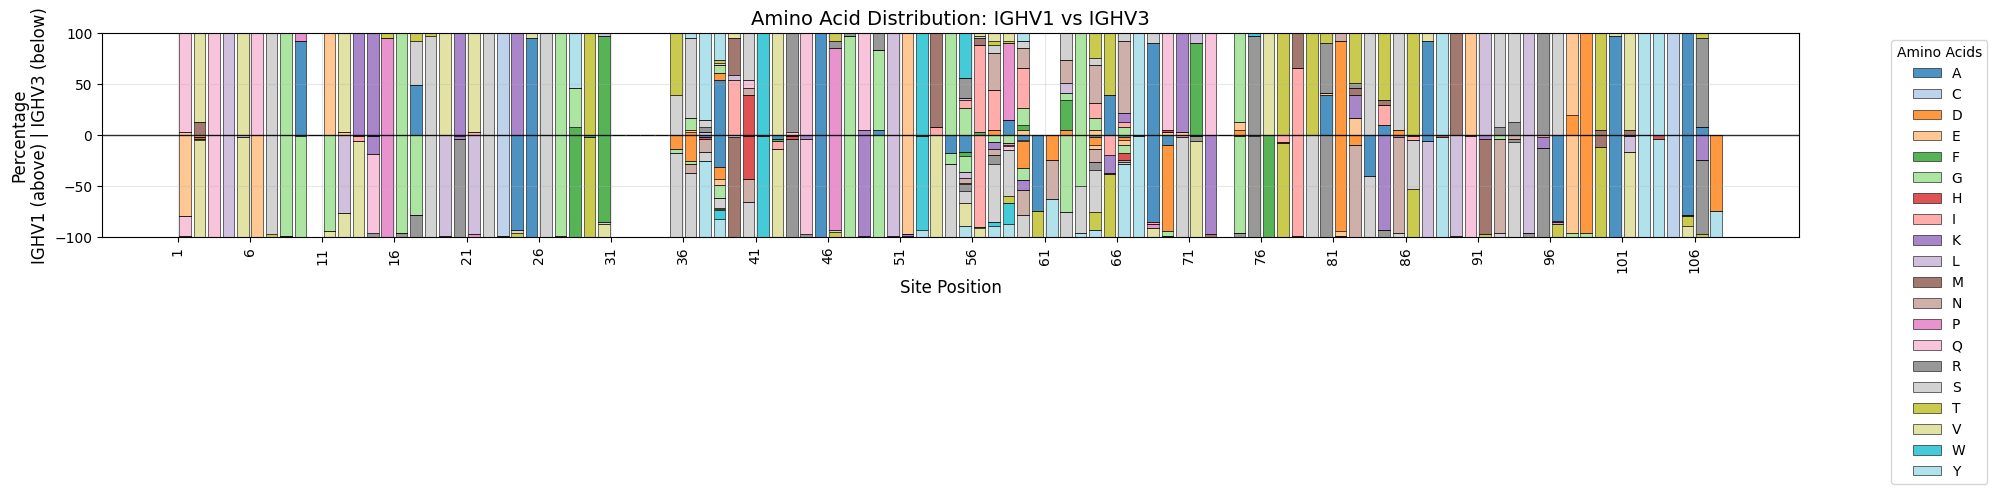

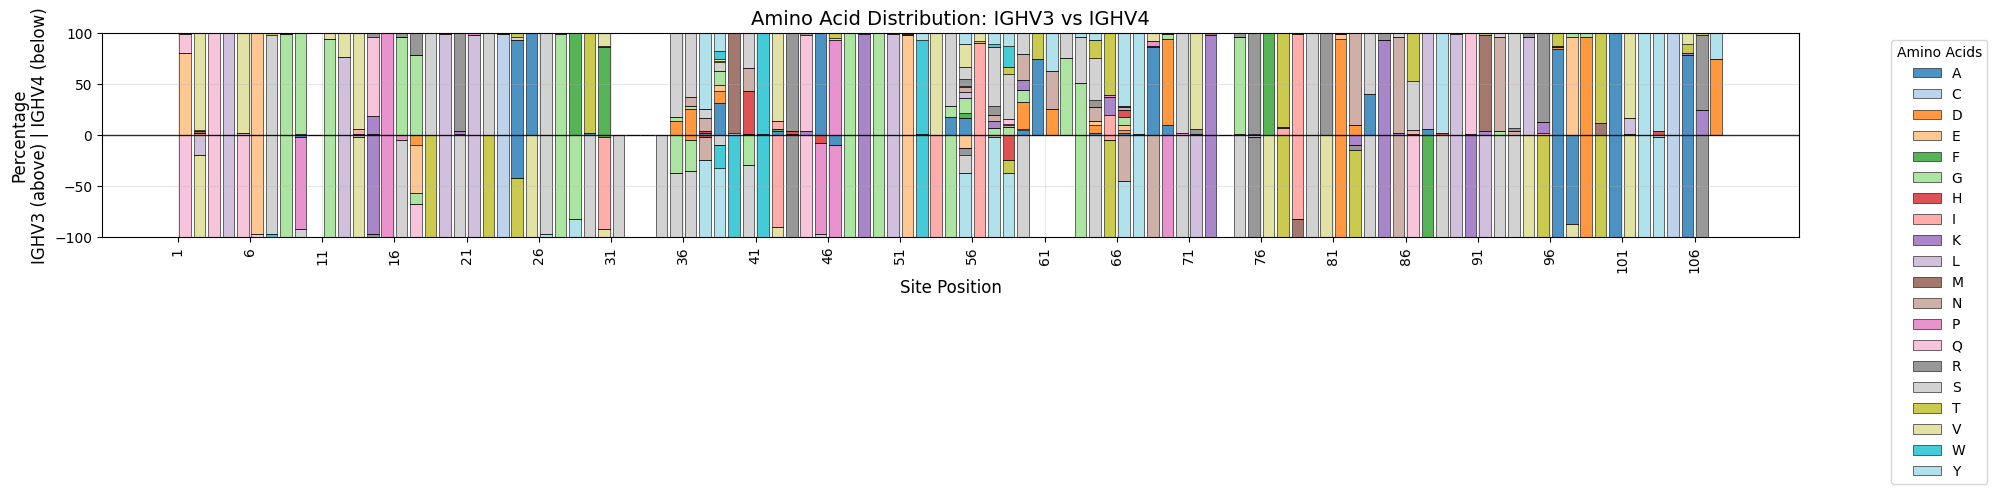

In [9]:
def plot_mirrored_vfamily_distribution(codons_df, v_family1, v_family2, figsize=(20, 4)):
    """
    Create a mirrored histogram showing amino acid distribution for two V families.
    v_family1 bars go above x-axis, v_family2 bars go below x-axis.
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Filter data for each family
    family1_data = codons_df[codons_df.v_family == v_family1].copy()
    family2_data = codons_df[codons_df.v_family == v_family2].copy()
    
    # Get common site range
    min_site = min(family1_data.site.min(), family2_data.site.min())
    max_site = max(family1_data.site.max(), family2_data.site.max())
    bins = range(min_site, max_site + 2)
    
    # Get all unique amino acids from both families
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap - specifically designed for 20 distinguishable colors
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate percentages for family1 (above x-axis)
    family1_counts = {}
    family1_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family1_counts[aa] = hist.astype(float)
        else:
            family1_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family1_totals += family1_counts[aa]
    
    # Convert to percentages
    for aa in all_amino_acids:
        family1_counts[aa] = np.divide(family1_counts[aa], family1_totals, 
                                     out=np.zeros_like(family1_counts[aa], dtype=float), 
                                     where=family1_totals!=0) * 100
    
    # Calculate percentages for family2 (below x-axis)
    family2_counts = {}
    family2_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family2_counts[aa] = hist.astype(float)
        else:
            family2_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family2_totals += family2_counts[aa]
    
    # Convert to percentages and make negative
    for aa in all_amino_acids:
        family2_counts[aa] = -np.divide(family2_counts[aa], family2_totals, 
                                      out=np.zeros_like(family2_counts[aa], dtype=float), 
                                      where=family2_totals!=0) * 100
    
    # Plot both families with consistent styling
    bin_centers = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]
    
    # Plot family1 above x-axis (positive values) - stack them
    bottom1 = np.zeros(len(bins)-1)
    for aa in all_amino_acids:
        if np.any(family1_counts[aa] > 0):
            ax.bar(bin_centers, family1_counts[aa], bottom=bottom1, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom1 += family1_counts[aa]
    
    # Plot family2 below x-axis (negative values) - stack them
    bottom2 = np.zeros(len(bins)-1)
    for aa in all_amino_acids:
        if np.any(family2_counts[aa] < 0):
            ax.bar(bin_centers, family2_counts[aa], bottom=bottom2, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom2 += family2_counts[aa]
    
    # Customize the plot
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel(f'Percentage\n{v_family1} (above) | {v_family2} (below)', fontsize=12)
    ax.set_title(f'Amino Acid Distribution: {v_family1} vs {v_family2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis ticks every 5 positions
    ax.set_xticks(range(min_site, max_site + 1, 5))
    plt.xticks(rotation=90)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5, alpha=0.8))
        legend_labels.append(aa)
    
    ax.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
              title='Amino Acids')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Usage example:
fig, ax = plot_mirrored_vfamily_distribution(codons_df, 'IGHV1', 'IGHV3')
fig, ax = plot_mirrored_vfamily_distribution(codons_df, 'IGHV3', 'IGHV4')